## Import the modules you need (this does not need to change)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import glob
import os
import matplotlib.cm as cm
import math as math
from scipy import signal
from scipy.fftpack import fft, ifft
from scipy.signal import savgol_filter
from collections import Counter
from ipywidgets import interactive
import _pickle as pickle

In [2]:
import time

In [3]:

import matplotlib 
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

## All the functions for plotting are in here

In [4]:
import LDQM_dataplot

importlib.reload(LDQM_dataplot)

<module 'LDQM_dataplot' from 'C:\\jdiez_local\\Code\\LDQM_dataplot.py'>

In [5]:
import capacitor_simulation

importlib.reload(capacitor_simulation)

<module 'capacitor_simulation' from 'C:\\jdiez_local\\Code\\capacitor_simulation.py'>

In [6]:
import basic_plotting

importlib.reload(basic_plotting)

<module 'basic_plotting' from 'C:\\jdiez_local\\Code\\basic_plotting.py'>

In [7]:
class Object():
    pass

# Parallel plate capacitor

## Load linescans of top gate and back gate for real data matching

In [11]:
directory = 'C:/jdiez_local/LDQM/a. Data/2021 February/'
BGTG_folder='JTB23/Data_0225/'
BGTG_directory= directory+BGTG_folder

BGTG_files=[
        '210224_J-TBG23_35mK_5nA_I-14-10_Rxx1-12-11_Rxx2-13-12_VSig-n6p5V_Vbg.txt',
               '210224_J-TBG23_35mK_5nA_I-14-10_Rxx1-12-11_Rxx2-13-12_VSig-n6p5V_Vtg_dn.txt',


]

BGTG_obj = {} #stores all the data
BGTG_raw ={} #store the xaxis data for plotting
BGTG_variables={} #store the data to plot in the right units
BGTG_name={}

# All IV curves

for i in range(len(BGTG_files)):
    file=BGTG_directory+BGTG_files[i]
    BGTG_obj['data'+str(i)],BGTG_variables['data'+str(i)],BGTG_name['data'+str(i)]=LDQM_dataplot.plot_lines_fromfiles(file)

    

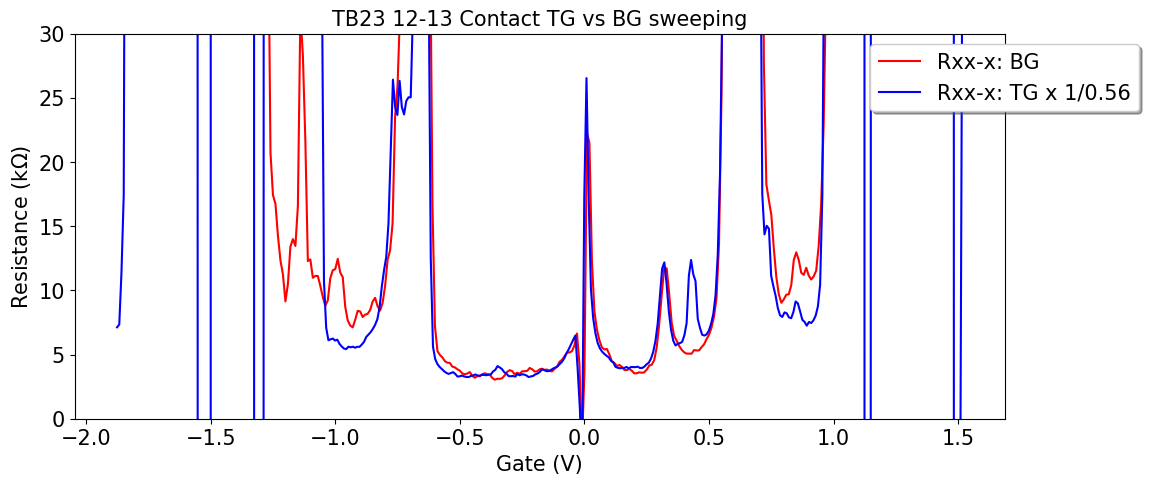

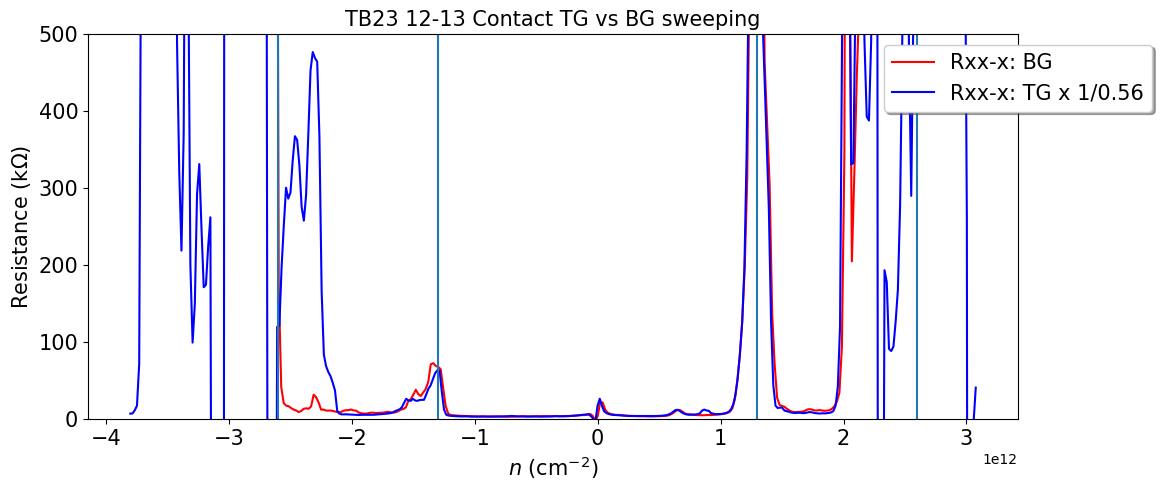

In [12]:
# Compare the contacts before and after etching. 

font=15
##R4-5 is ICE 2-3 and BF1 17-18
x_conversion=0.0058/1.602E-19/1E4*0.56


xbg=BGTG_obj['data0'].BackgateVoltage

x0=max(xbg[int(len(xbg)/2):int(len(xbg)/2)+10])
x0bg=0.11

ybg=BGTG_obj['data0'].Rxx_2X
Ibg=BGTG_obj['data0'].CurrentR
Rbg=ybg/Ibg/1000
nbg=(xbg-x0bg)*x_conversion

'''
x=BF1_cont_obj['data0'].SigateSourcevoltage
x0=max(x[int(len(x)/2)-10:int(len(x)/2)+10])
y=BF1_cont_obj['data0'].Rxx2X
I=BF1_cont_obj['data0'].CurrentR
plt.plot(x-x0,y/I/1000,label='Rxx-x: BF1 7-8 37 mK',color='k')
'''
xtg=BGTG_obj['data1'].TopgateTG1TG5/0.56
x0=max(xbg[int(len(xbg)/2):int(len(xbg)/2)+5])
x0tg=0.09

ytg=BGTG_obj['data1'].Rxx_2X
Itg=BGTG_obj['data1'].CurrentR
Rtg=ytg/Itg/1000
ntg=(xtg-x0tg)*x_conversion

plt.figure(figsize=(12,5))
plt.plot(xbg-x0bg,Rbg,label='Rxx-x: BG',color='r')
plt.plot(xtg-x0tg,Rtg,label='Rxx-x: TG x 1/0.56',color='b')

plt.plot(xbg,xbg*0,linewidth=0.5,linestyle='dashed',color='grey')
plt.legend()
plt.ylim(0,30)
#plt.xlim(-0.8,0.8)
plt.title('TB23 12-13 Contact TG vs BG sweeping',fontsize=font)
plt.xlabel('Gate (V)',fontsize=font)
plt.ylabel('Resistance (k$\Omega$)',fontsize=font)
plt.legend(loc='upper center', bbox_to_anchor=(1, 1), shadow=True, ncol=1,fontsize=font)
plt.tick_params(axis='both',which='major',labelsize=font)

#plt.yscale('log')

plt.show()

plt.figure(figsize=(12,5))

plt.plot(nbg,Rbg,label='Rxx-x: BG',color='r')
plt.plot(ntg,Rtg,label='Rxx-x: TG x 1/0.56',color='b')

plt.plot(xbg,xbg*0,linewidth=0.5,linestyle='dashed',color='grey')
plt.legend()
plt.ylim(0,500)

plt.title('TB23 12-13 Contact TG vs BG sweeping',fontsize=font)
plt.xlabel('$n$ (cm$^{-2}$)',fontsize=font)
plt.ylabel('Resistance (k$\Omega$)',fontsize=font)
plt.legend(loc='upper center', bbox_to_anchor=(1, 1), shadow=True, ncol=1,fontsize=font)
plt.tick_params(axis='both',which='major',labelsize=font)
plt.axvline(x=1.3E12)
plt.axvline(x=-1.3E12)
plt.axvline(x=2.6E12)
plt.axvline(x=-2.6E12)

#plt.yscale('log')

plt.show()

In [13]:
## Make a fucnion for the carrier density and the resistance 

def get_R(n,realn,realR):
    for i in range(len(realn)):
        if n==realn[i] :
            position=i  
        elif n<realn[i] and n>realn[i-1]:
            position=i   
        
    return realR[position]

def get_I(n,realn,realI):
    for i in range(len(realn)):
        if n==realn[i] :
            position=i  
        elif n<realn[i] and n>realn[i-1]:
            position=i
    return realI[position]

# Does it work? --> Yes

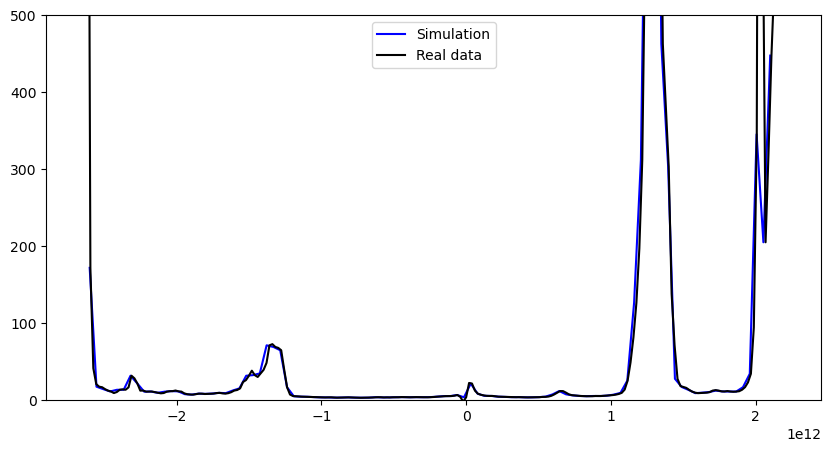

In [14]:
new_n=np.linspace(-2.6E12,2.1E12,101)
R_new=np.zeros_like(new_n)

for i in range(len(new_n)):
    R_new[i]=get_R(new_n[i],nbg,Rbg)
plt.figure(figsize=(10,5))   
plt.plot(new_n,R_new,'b',label='Simulation')    
plt.plot(nbg,Rbg,'k',label='Real data')  
plt.ylim(0,500)
plt.legend()
plt.show()

## Make a simulation of the double gated map

In [15]:



hBN_ratio=0.56
C_bot=0.0058/1.602E-19/1E4*hBN_ratio
C_top=0.0058/1.602E-19/1E4
V_bot=np.linspace(xbg[0],xbg[-1],401)
V_top=np.linspace(xtg[-1],xtg[0],401)

new_nbg=V_bot*C_bot
new_ntg=V_top*C_top

map_R=np.zeros((len(new_ntg),len(new_nbg)))
map_R_cut=np.zeros((len(new_ntg),len(new_nbg)))
total_R=np.zeros((len(new_ntg),len(new_nbg)))
map_n=np.zeros_like(map_R)
map_n_cut=np.zeros_like(map_R)
# make a n grid

NBG,NTG=np.meshgrid(new_nbg,new_ntg)
VBG,VTG=np.meshgrid(V_bot,V_top)
# Get the carrier density 

for i in range(len(new_ntg)):
    for j in range(len(new_nbg)):
        map_n[i,j]=new_ntg[i]+new_nbg[j]
        map_n_cut[i,j]=new_nbg[j] 
# Get the signal from the hall bar

for i in range(len(new_ntg)):
    for j in range(len(new_nbg)):
        if abs(map_n[i,j])>max(nbg):
            map_R[i,j]=0
        else:
            map_R[i,j]=get_R(map_n[i,j],nbg,Rbg)
            
# Make a signal from the cut 
for i in range(len(new_ntg)):
    for j in range(len(new_nbg)):
        if abs(map_n_cut[i,j])>max(nbg):
            map_R_cut[i,j]=0
        else:
            map_R_cut[i,j]=get_R(map_n_cut[i,j],nbg,Rbg)


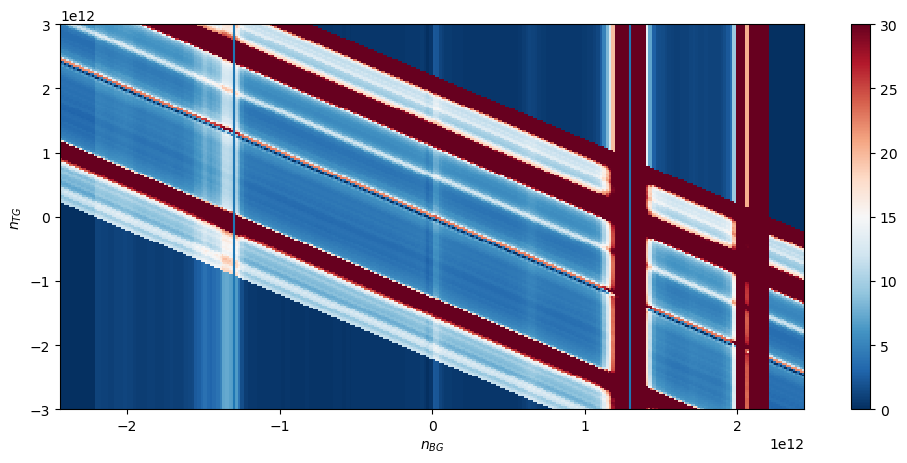

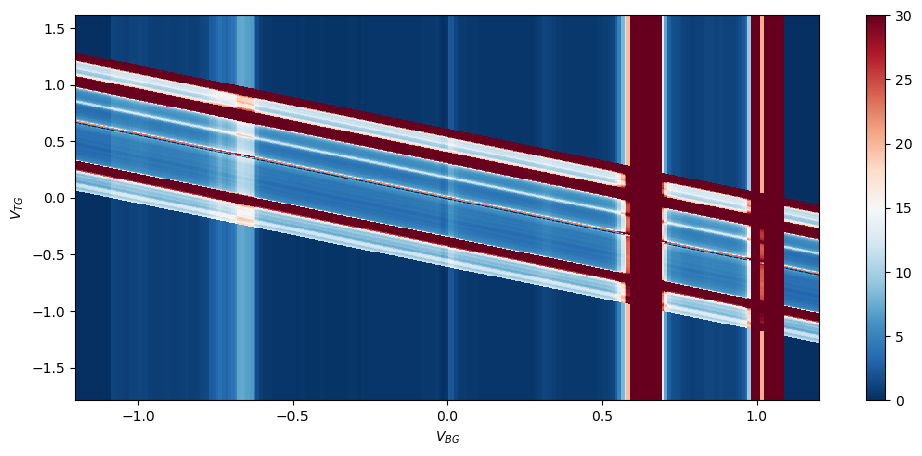

In [16]:
# Combine it             
for i in range(len(new_ntg)):
    for j in range(len(new_nbg)):
        total_R[i,j]=map_R[i,j]+map_R_cut[i,j]*0.1

plt.figure(figsize=(12,5))
plt.pcolormesh(NBG,NTG,total_R,cmap='RdBu_r',vmin=0,vmax=30)
plt.xlabel('$n_{BG}$')
plt.ylabel('$n_{TG}$')
plt.ylim(-3E12,3E12)
plt.axvline(x=1.3E12)
plt.axvline(x=-1.3E12)

plt.colorbar()
plt.show()

plt.figure(figsize=(12,5))
plt.pcolormesh(VBG,VTG,total_R,cmap='RdBu_r',vmin=0,vmax=30)
plt.xlabel('$V_{BG}$')
plt.ylabel('$V_{TG}$')
#plt.ylim(-2.5E12,2.5E12)
plt.colorbar()
plt.show()

# Do the model in real data

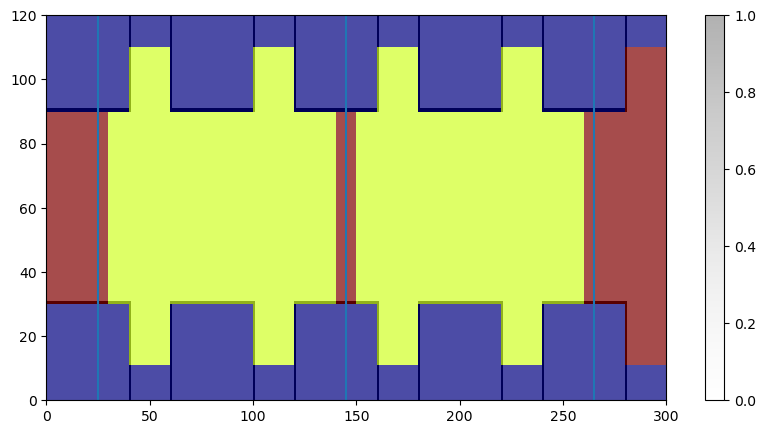

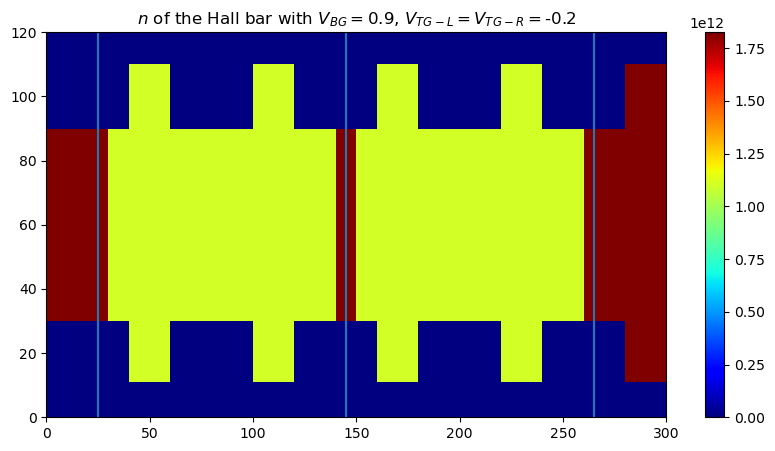

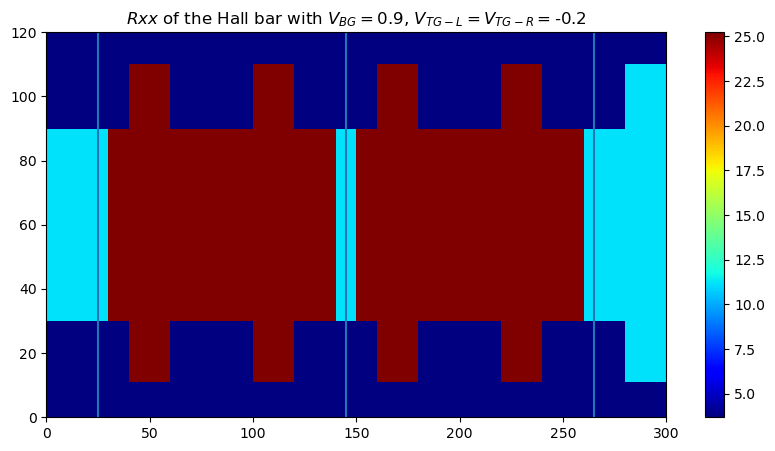

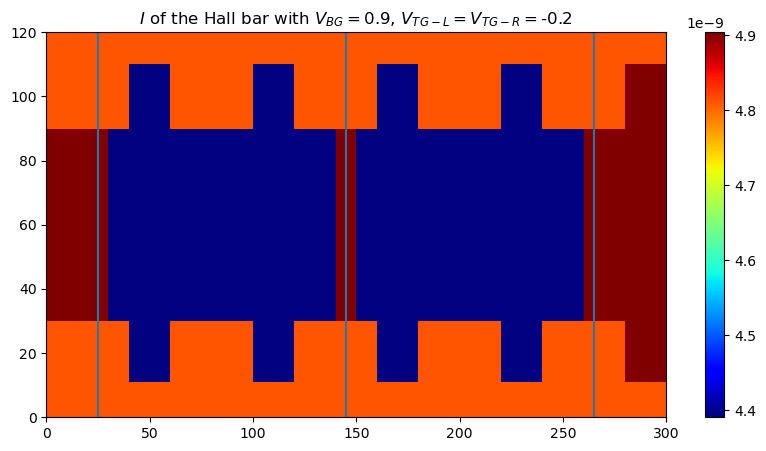

In [17]:
### Cuts in everyelectrode

# parallel plate capacitor

# Set dimensions of the problem
HB_width=30  # half of the real width 
HB_len=300
arms_width=10  # half of the real width
arms_len=30
gr_top_width=50
gr_bot_width=40
num_arms=6
arms_dis=int(HB_len/num_arms)

cut_width=5
cut1=int(arms_dis/2)
cut2=2*(arms_dis+arms_width)+int(arms_dis/2)
cut3=4*(arms_dis+arms_width)+int(arms_dis/2)



Nx=HB_len
Ny=2*HB_width+2*arms_len
center_x=int(Nx/2)
center_y=int(Ny/2)

x=np.arange(0,Nx+1,1)
y=np.arange(0,Ny+1,1)
x_real=np.arange(-center_x,center_x+1,1)
y_real=np.arange(-center_y,center_y+1,1)

X,Y=np.meshgrid(x,y)
X_R,Y_R=np.meshgrid(x_real,y_real)
# Make the matrix for the hall bar shape. In np.zeros, the order is inverted

border=np.zeros((Ny,Nx))

# Make the zeros for the carrier density guess for out matrix --> All 0s

n=np.zeros((Ny,Nx))
V_top=np.zeros((Ny,Nx))
V_bot=np.zeros((Ny,Nx))
C_bot=0.0058/1.602E-19/1E4*0.56
C_top=0.0058/1.602E-19/1E4
# Hall bar width lets make it 100, length 300, arms every 50 with width of 10 and length of 20
### lets give a value of 1 to the border, so I plot in black and white just the border of the hall bar

count=0
for k in range(num_arms):
    for j in range(Nx):
        for i in range(Ny):
            if j in range(0+count,(arms_dis-arms_width)+count):
                if i==center_y-HB_width or i==center_y+HB_width:
                    border[i,j]=1
            if j==(arms_dis-arms_width)+count and i>=center_y+HB_width:
                border[i,j]=1   
            if j ==(arms_dis+arms_width)+count and i>=center_y+HB_width:
                border[i,j]=1   
            if j==(arms_dis-arms_width)+count and i<=center_y-HB_width:
                border[i,j]=1   
            if j==(arms_dis+arms_width)+count and i<=center_y-HB_width:
                border[i,j]=1 
    count=count+(arms_dis+arms_width)
    
### Fill the resistance values

V_bg=0.9
V_tg1=0
V_tg2=-0.2
V_tg3=-0.2
V_tg4=0
V_tg5=0
V_tg6=0

count=0
for j in range(Nx):
    for i in range(Ny):
        # Left of 1st cut
        if j in range(0,cut1-cut_width):
            for i in range(center_y-HB_width,center_y+HB_width):
                V_top[i,j]=V_tg1
                V_bot[i,j]=V_bg
                
        # Inside of 1st cut
        if j in range(cut1-cut_width,cut1+cut_width):
            for i in range(center_y-HB_width,center_y+HB_width):
                V_top[i,j]=0
                V_bot[i,j]=V_bg
                
        # Between two cuts
        if j in range(cut1+cut_width,cut2-cut_width):
            for i in range(center_y-HB_width,center_y+HB_width):
                V_top[i,j]=V_tg2
                V_bot[i,j]=V_bg
                
        # Inside of 2nd cut
        if j in range(cut2-cut_width,cut2+cut_width):
            for i in range(center_y-HB_width,center_y+HB_width):
                V_top[i,j]=0
                V_bot[i,j]=V_bg
                
        # Right of 2nd cut
        if j in range(cut2+cut_width,cut3-cut_width):
            for i in range(center_y-HB_width,center_y+HB_width):
                V_top[i,j]=V_tg3
                V_bot[i,j]=V_bg
        # Inside of 3nd cut
        if j in range(cut3-cut_width,cut3+cut_width):
            for i in range(center_y-HB_width,center_y+HB_width):
                V_top[i,j]=0
                V_bot[i,j]=V_bg
                
        # Right of 3nd cut
        if j in range(cut3+cut_width,Nx):
            for i in range(center_y-HB_width,center_y+HB_width):
                V_top[i,j]=V_tg4
                V_bot[i,j]=V_bg

                
### This is the arms 

for k in range(num_arms):
    for j in range(Nx):
        for i in range(Ny):
            
            if j in range(arms_dis-arms_width+count,arms_dis+arms_width+count):
                if i>=center_y+HB_width and i<center_y+gr_top_width:
                    V_top[i,j]=V_top[center_y,j]   
                    V_bot[i,j]=V_bot[center_y,j]  
                elif i>=center_y+gr_top_width and i<center_y+gr_bot_width:
                    V_top[i,j]=0  
                    V_bot[i,j]=V_bot[center_y,j]  
                elif i<=center_y-gr_bot_width and i>center_y-gr_top_width:
                    V_top[i,j]=V_top[center_y,j]  
                    V_bot[i,j]=0
                    
            if j in range(arms_dis-arms_width+count,arms_dis+arms_width+count):
                if i<=center_y-HB_width and i>center_y-gr_top_width:
                    V_top[i,j]=V_top[center_y,j]   
                    V_bot[i,j]=V_bot[center_y,j]  
                elif i<=center_y-gr_top_width and i>center_y-gr_bot_width:
                    V_top[i,j]=0  
                    V_bot[i,j]=V_bot[center_y,j]  
                elif i<=center_y-gr_bot_width and i>center_y-gr_top_width:
                    V_top[i,j]=V_top[center_y,j]  
                    V_bot[i,j]=0
                
    count=count+(arms_dis+arms_width)

n=V_top*C_top+V_bot*C_bot  

R=np.zeros_like(n)
I=np.zeros_like(n)
for i in range(len(n)):
    for j in range(len(n[0])):
        R[i,j]=get_R(n[i,j],nbg,Rbg)
        I[i,j]=get_I(n[i,j],nbg,Ibg)
    
plt.figure(figsize=(10,5))    

plt.axvline(x=cut1)
plt.axvline(x=cut2)
plt.axvline(x=cut3)
plt.pcolormesh(X,Y,n,cmap='jet')
plt.pcolormesh(X,Y,border,cmap='Greys',alpha=0.3)
plt.colorbar()
plt.show()

plt.figure(figsize=(10,5))    

plt.axvline(x=cut1)
plt.axvline(x=cut2)
plt.axvline(x=cut3)
plt.pcolormesh(X,Y,n,cmap='jet')
plt.title('$n$ of the Hall bar with $V_{BG}=$'+str(V_bg)+', $V_{TG-L}=V_{TG-R}=$'+str(V_tg3))
plt.colorbar()
plt.show()

plt.figure(figsize=(10,5))    

plt.axvline(x=cut1)
plt.axvline(x=cut2)
plt.axvline(x=cut3)
plt.pcolormesh(X,Y,R,cmap='jet')
plt.title('$Rxx$ of the Hall bar with $V_{BG}=$'+str(V_bg)+', $V_{TG-L}=V_{TG-R}=$'+str(V_tg3))
plt.colorbar()
plt.show()

plt.figure(figsize=(10,5))    

plt.axvline(x=cut1)
plt.axvline(x=cut2)
plt.axvline(x=cut3)
plt.pcolormesh(X,Y,I,cmap='jet')
plt.title('$I$ of the Hall bar with $V_{BG}=$'+str(V_bg)+', $V_{TG-L}=V_{TG-R}=$'+str(V_tg3))
plt.colorbar()
plt.show()



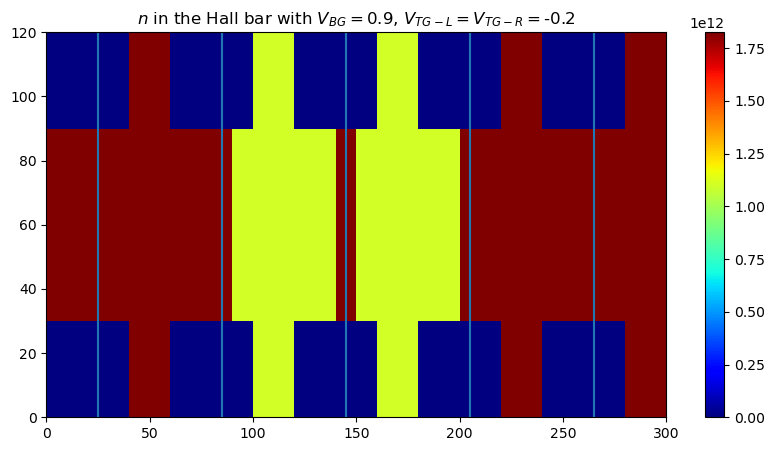

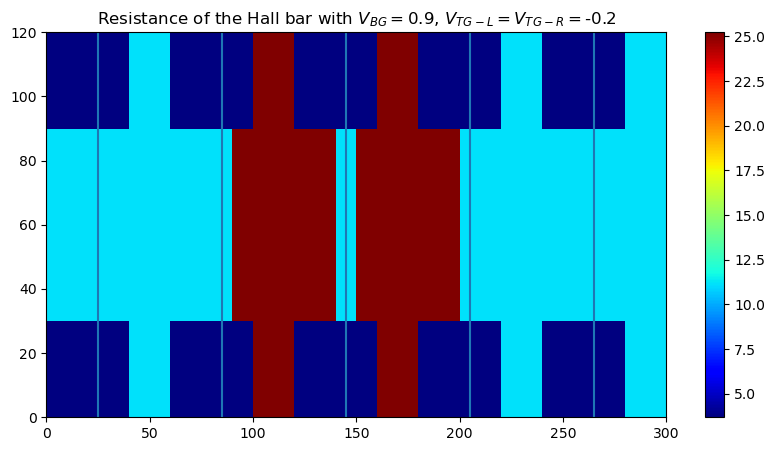

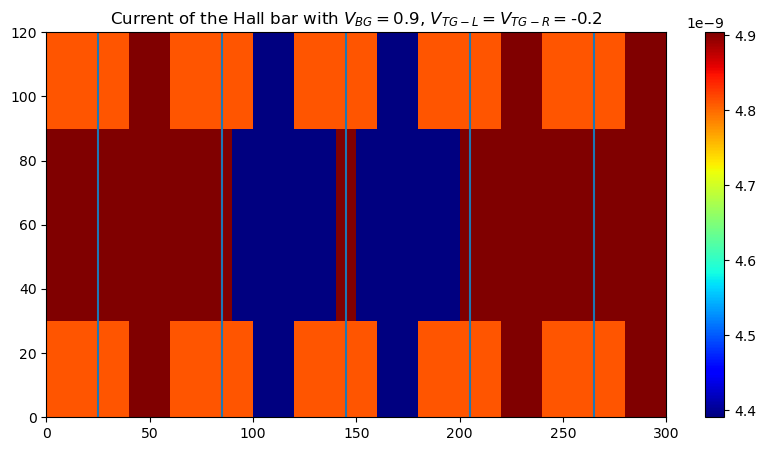

In [18]:
### Cuts in every electrode

# parallel plate capacitor

# Set dimensions of the problem
HB_width=30  # half of the real width 
HB_len=300
arms_width=10  # half of the real width
arms_len=30
gr_top_width=110
gr_bot_width=120
num_arms=6
arms_dis=int(HB_len/num_arms)

cut_width=5
cut1=int(arms_dis/2)
cut2=(arms_dis+arms_width)+int(arms_dis/2)
cut3=2*(arms_dis+arms_width)+int(arms_dis/2)
cut4=3*(arms_dis+arms_width)+int(arms_dis/2)
cut5=4*(arms_dis+arms_width)+int(arms_dis/2)


Nx=HB_len
Ny=2*HB_width+2*arms_len
center_x=int(Nx/2)
center_y=int(Ny/2)

x=np.arange(0,Nx+1,1)
y=np.arange(0,Ny+1,1)
x_real=np.arange(-center_x,center_x+1,1)
y_real=np.arange(-center_y,center_y+1,1)

X,Y=np.meshgrid(x,y)
X_R,Y_R=np.meshgrid(x_real,y_real)
# Make the matrix for the hall bar shape. In np.zeros, the order is inverted

border=np.zeros((Ny,Nx))

# Make the zeros for the carrier density guess for out matrix --> All 0s

n=np.zeros((Ny,Nx))
V_top=np.zeros((Ny,Nx))
V_bot=np.zeros((Ny,Nx))
C_bot=0.0058/1.602E-19/1E4*0.56
C_top=0.0058/1.602E-19/1E4
# Hall bar width lets make it 100, length 300, arms every 50 with width of 10 and length of 20
### lets give a value of 1 to the border, so I plot in black and white just the border of the hall bar

count=0
for k in range(num_arms):
    for j in range(Nx):
        for i in range(Ny):
            if j in range(0+count,(arms_dis-arms_width)+count):
                if i==center_y-HB_width or i==center_y+HB_width:
                    border[i,j]=1
            if j==(arms_dis-arms_width)+count and i>=center_y+HB_width:
                border[i,j]=1   
            if j ==(arms_dis+arms_width)+count and i>=center_y+HB_width:
                border[i,j]=1   
            if j==(arms_dis-arms_width)+count and i<=center_y-HB_width:
                border[i,j]=1   
            if j==(arms_dis+arms_width)+count and i<=center_y-HB_width:
                border[i,j]=1 
    count=count+(arms_dis+arms_width)
    
### Fill the resistance values

V_bg=0.9
V_tg1=0
V_tg2=0
V_tg3=-0.2
V_tg4=-0.2
V_tg5=0
V_tg6=0

count=0
for j in range(Nx):
    for i in range(Ny):
        # Left of 1st cut
        if j in range(0,cut1-cut_width):
            for i in range(center_y-HB_width,center_y+HB_width):
                V_top[i,j]=V_tg1
                V_bot[i,j]=V_bg
                
        # Inside of 1st cut
        if j in range(cut1-cut_width,cut1+cut_width):
            for i in range(center_y-HB_width,center_y+HB_width):
                V_top[i,j]=0
                V_bot[i,j]=V_bg
                
        # Between two cuts
        if j in range(cut1+cut_width,cut2-cut_width):
            for i in range(center_y-HB_width,center_y+HB_width):
                V_top[i,j]=V_tg2
                V_bot[i,j]=V_bg
                
        # Inside of 2nd cut
        if j in range(cut2-cut_width,cut2+cut_width):
            for i in range(center_y-HB_width,center_y+HB_width):
                V_top[i,j]=0
                V_bot[i,j]=V_bg
                
        # Right of 2nd cut
        if j in range(cut2+cut_width,cut3-cut_width):
            for i in range(center_y-HB_width,center_y+HB_width):
                V_top[i,j]=V_tg3
                V_bot[i,j]=V_bg
        # Inside of 3nd cut
        if j in range(cut3-cut_width,cut3+cut_width):
            for i in range(center_y-HB_width,center_y+HB_width):
                V_top[i,j]=0
                V_bot[i,j]=V_bg
                
        # Right of 3nd cut
        if j in range(cut3+cut_width,cut4-cut_width):
            for i in range(center_y-HB_width,center_y+HB_width):
                V_top[i,j]=V_tg4
                V_bot[i,j]=V_bg
        # Inside of 4th cut
        if j in range(cut4-cut_width,cut4+cut_width):
            for i in range(center_y-HB_width,center_y+HB_width):
                V_top[i,j]=0
                V_bot[i,j]=V_bg
                
        # Right of 4th cut
        if j in range(cut4-cut_width,cut5-cut_width):
            for i in range(center_y-HB_width,center_y+HB_width):
                V_top[i,j]=V_tg5
                V_bot[i,j]=V_bg
                
        # Inside of 5th cut
        if j in range(cut5-cut_width,cut5+cut_width):
            for i in range(center_y-HB_width,center_y+HB_width):
                V_top[i,j]=0
                V_bot[i,j]=V_bg
                
        # Right of 5th cut
        if j in range(cut5+cut_width,Nx):
            for i in range(center_y-HB_width,center_y+HB_width):
                V_top[i,j]=V_tg6
                V_bot[i,j]=V_bg
                
### This is the arms 

for k in range(num_arms):
    for j in range(Nx):
        for i in range(Ny):
            if j in range(arms_dis-arms_width+count,arms_dis+arms_width+count) and i>=center_y+HB_width:
                V_top[i,j]=V_top[center_y,j]   
                V_bot[i,j]=V_bot[center_y,j]  
            if j in range(arms_dis-arms_width+count,arms_dis+arms_width+count) and i>=center_y+HB_width:
                V_top[i,j]=V_top[center_y,j]   
                V_bot[i,j]=V_bot[center_y,j]  
            if j in range(arms_dis-arms_width+count,arms_dis+arms_width+count) and i<=center_y-HB_width:
                V_top[i,j]=V_top[center_y,j]   
                V_bot[i,j]=V_bot[center_y,j]  
            if j in range(arms_dis-arms_width+count,arms_dis+arms_width+count) and i<=center_y-HB_width:
                V_top[i,j]=V_top[center_y,j]   
                V_bot[i,j]=V_bot[center_y,j]    
                
    count=count+(arms_dis+arms_width)

n=V_top*C_top+V_bot*C_bot   

R=np.zeros_like(n)
I=np.zeros_like(n)

for i in range(len(n)):
    for j in range(len(n[0])):
        R[i,j]=get_R(n[i,j],nbg,Rbg)
        I[i,j]=get_I(n[i,j],nbg,Ibg)
'''
plt.figure(figsize=(10,5))    

plt.axvline(x=cut1)
plt.axvline(x=cut2)
plt.axvline(x=cut3)
plt.pcolormesh(X,Y,n,cmap='jet')
plt.pcolormesh(X,Y,border,cmap='Greys',alpha=0.3)
plt.colorbar()
plt.show()
'''
plt.figure(figsize=(10,5))    

plt.axvline(x=cut1)
plt.axvline(x=cut2)
plt.axvline(x=cut3)
plt.axvline(x=cut4)
plt.axvline(x=cut5)
plt.pcolormesh(X,Y,n,cmap='jet')
plt.colorbar()
plt.title('$n$ in the Hall bar with $V_{BG}=$'+str(V_bg)+', $V_{TG-L}=V_{TG-R}=$'+str(V_tg3))
plt.show()

plt.figure(figsize=(10,5))    

plt.axvline(x=cut1)
plt.axvline(x=cut2)
plt.axvline(x=cut3)
plt.axvline(x=cut4)
plt.axvline(x=cut5)
plt.pcolormesh(X,Y,R,cmap='jet')
plt.colorbar()
plt.title('Resistance of the Hall bar with $V_{BG}=$'+str(V_bg)+', $V_{TG-L}=V_{TG-R}=$'+str(V_tg3))
plt.show()

plt.figure(figsize=(10,5))    

plt.axvline(x=cut1)
plt.axvline(x=cut2)
plt.axvline(x=cut3)
plt.axvline(x=cut4)
plt.axvline(x=cut5)
plt.pcolormesh(X,Y,I,cmap='jet')
plt.title('Current of the Hall bar with $V_{BG}=$'+str(V_bg)+', $V_{TG-L}=V_{TG-R}=$'+str(V_tg3))
plt.colorbar()
plt.show()


# Trilayer simulation 

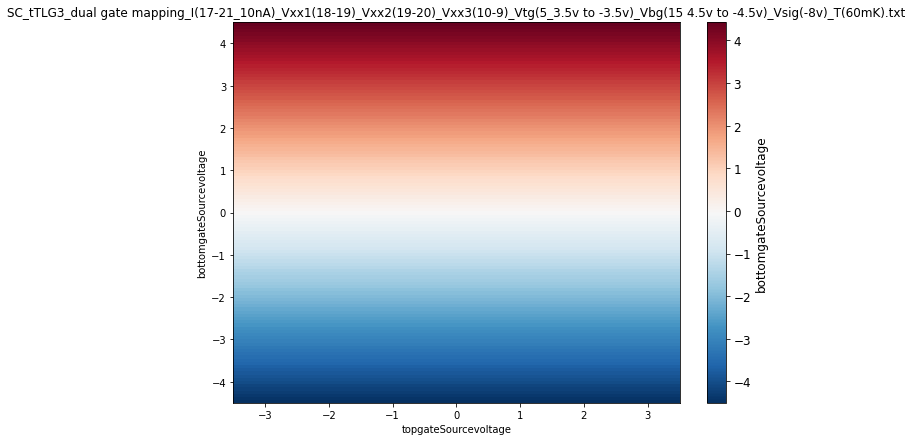

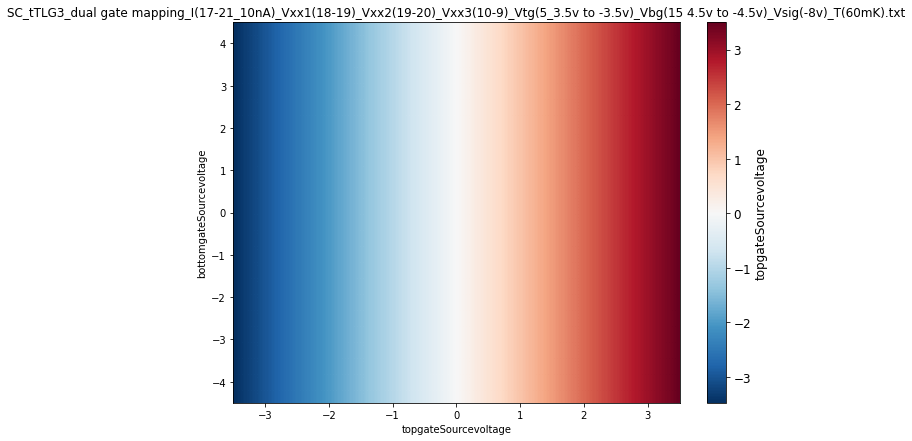

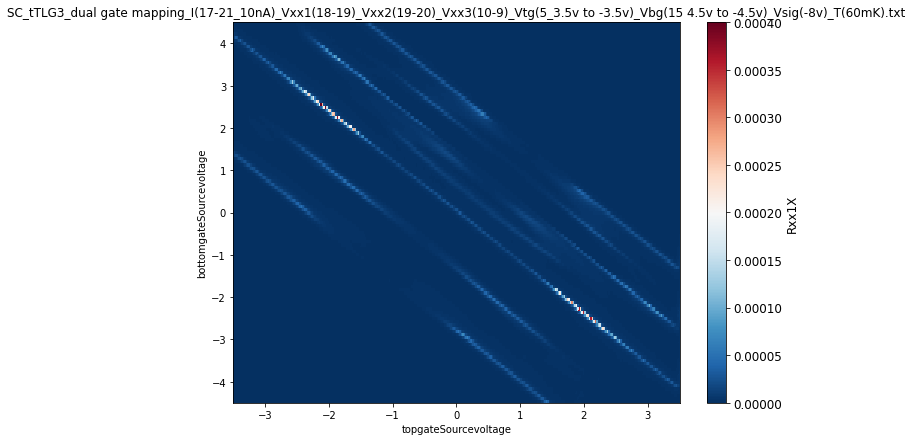

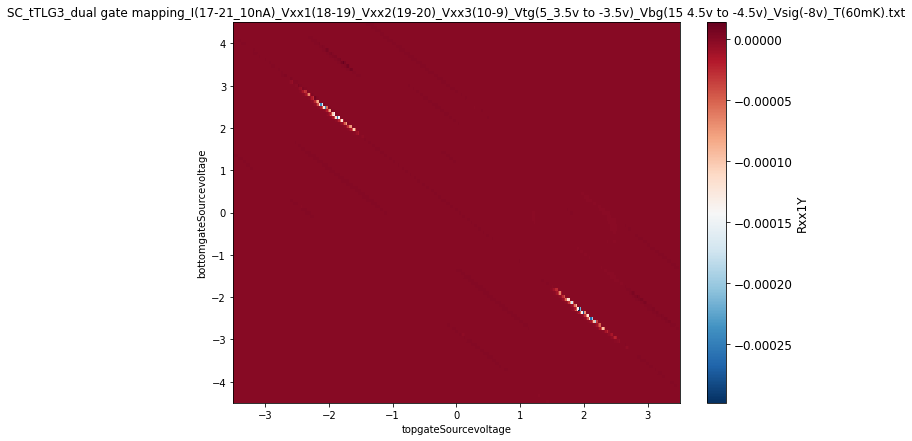

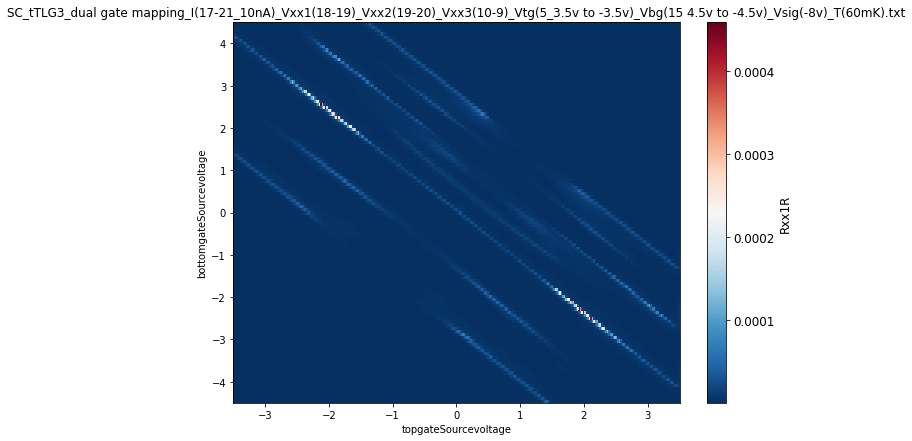

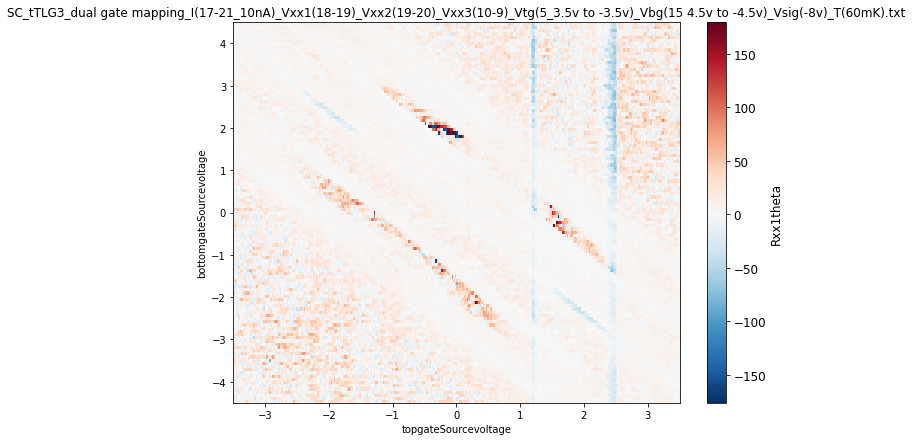

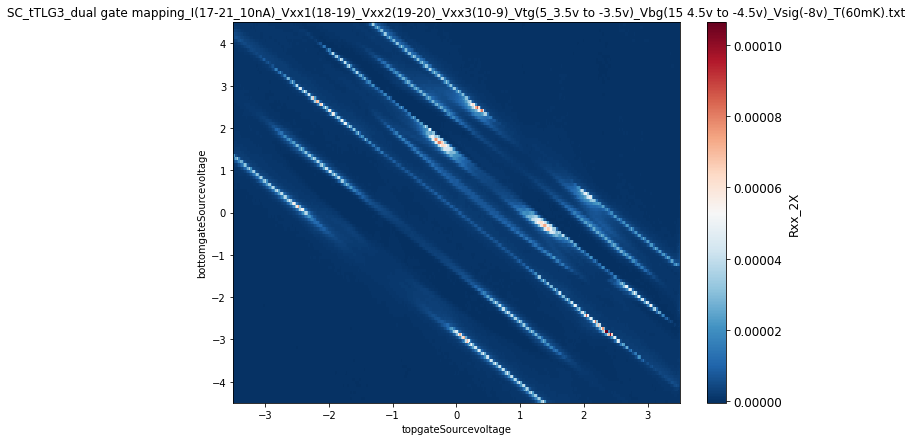

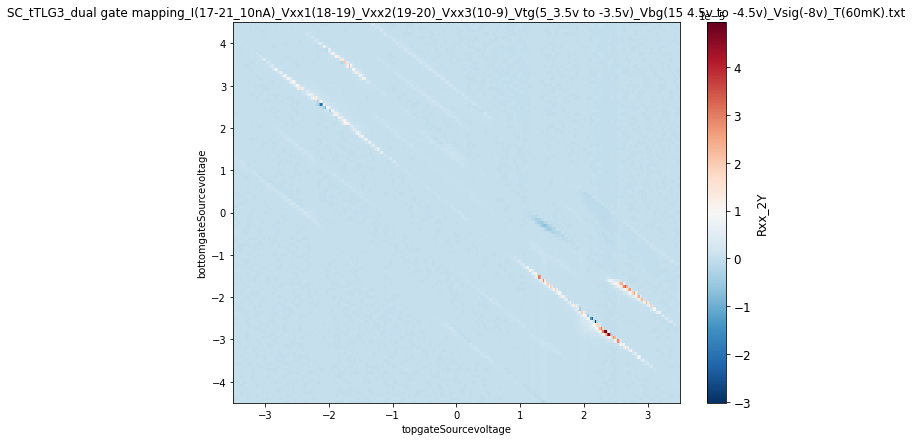

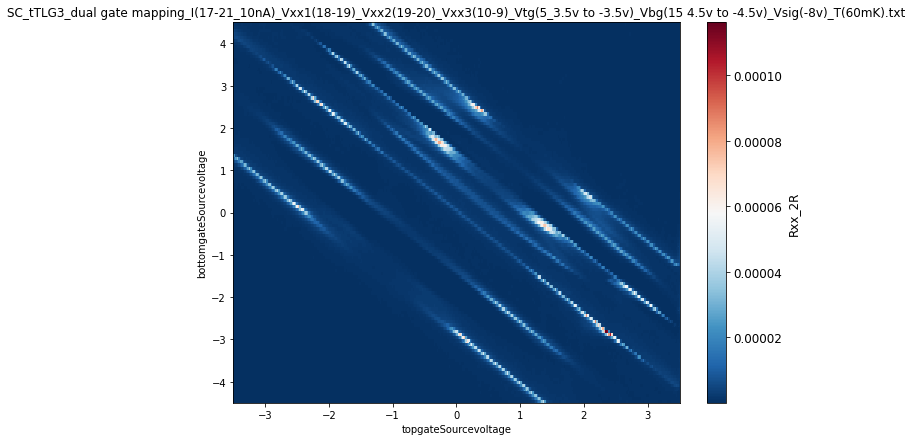

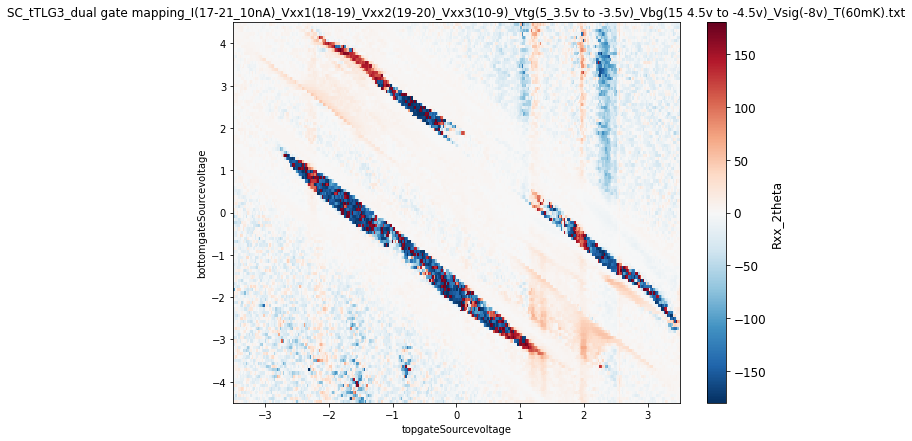

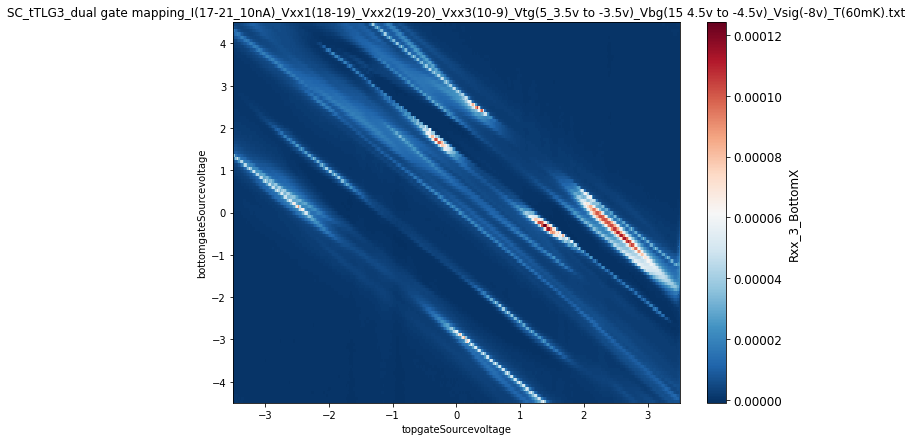

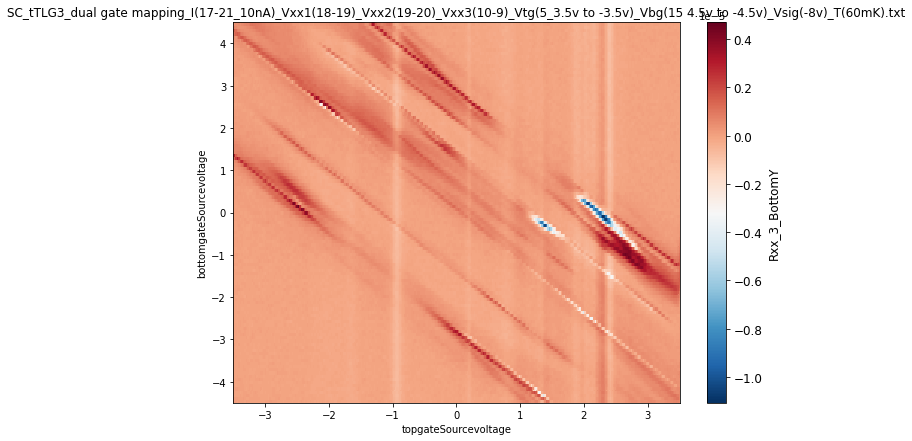

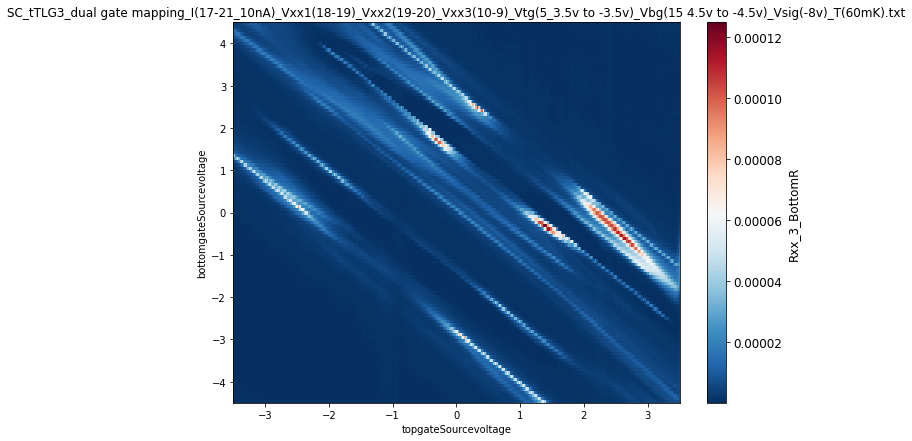

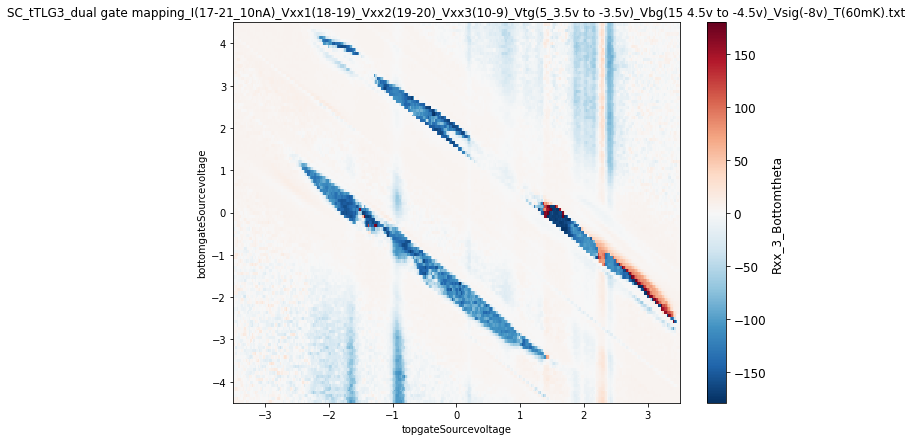

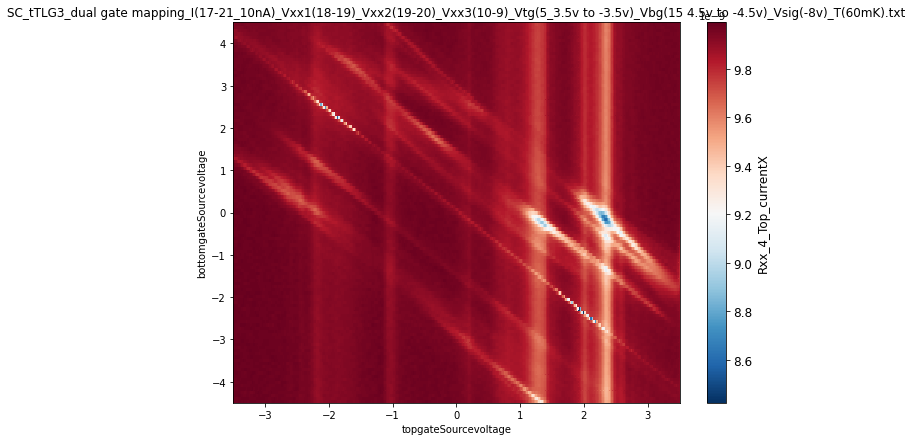

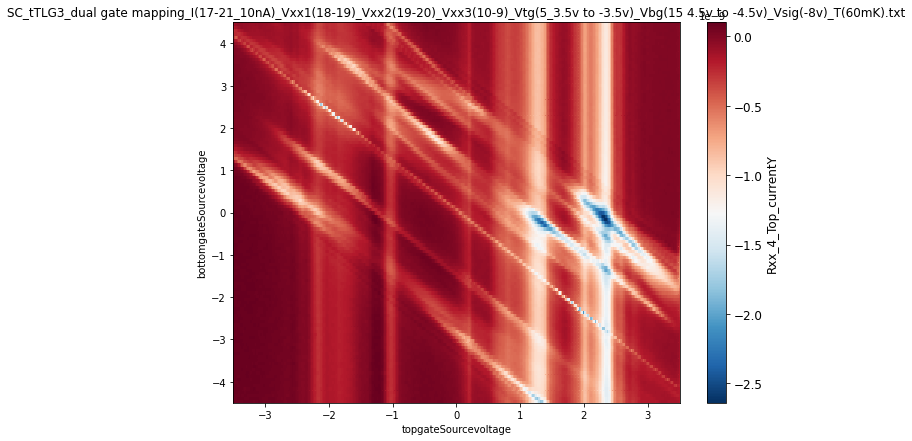

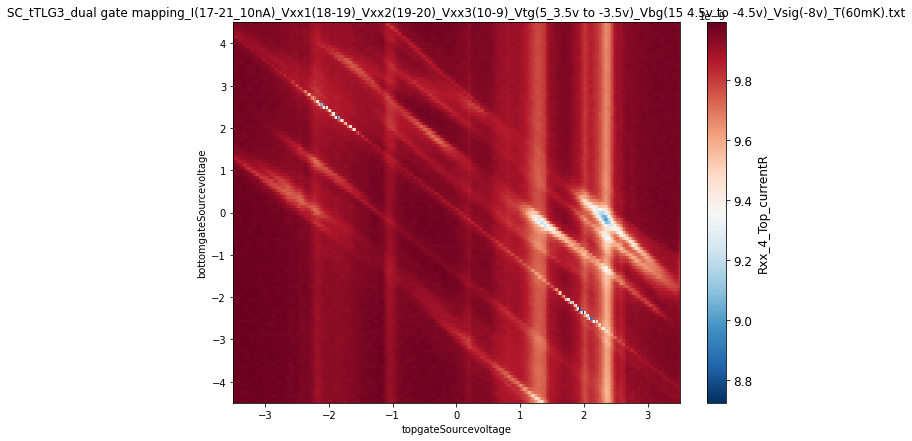

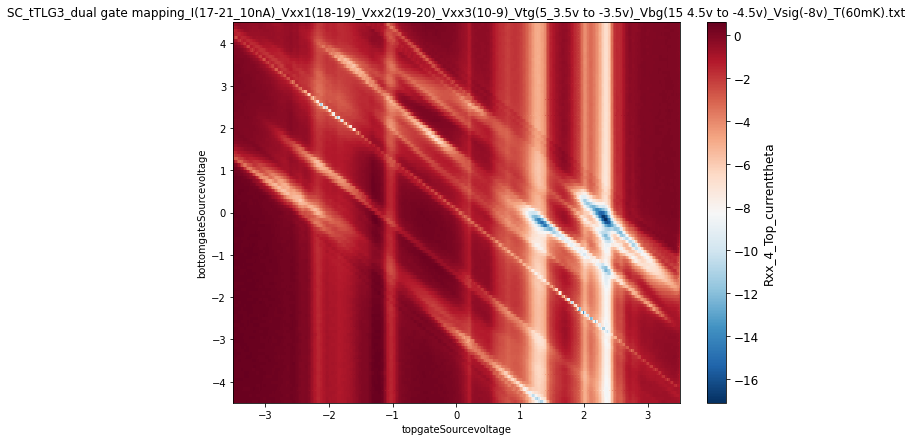

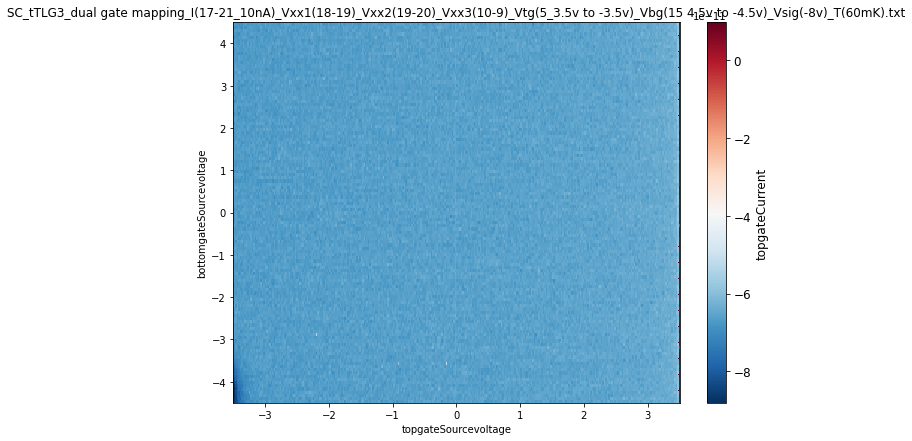

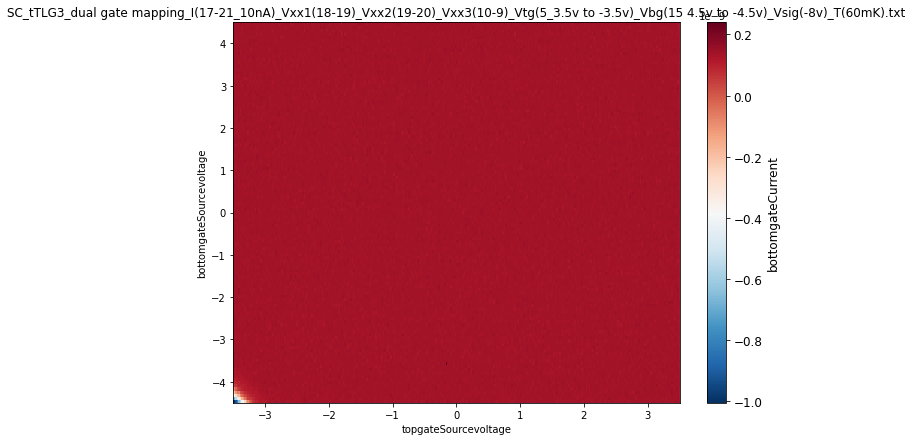

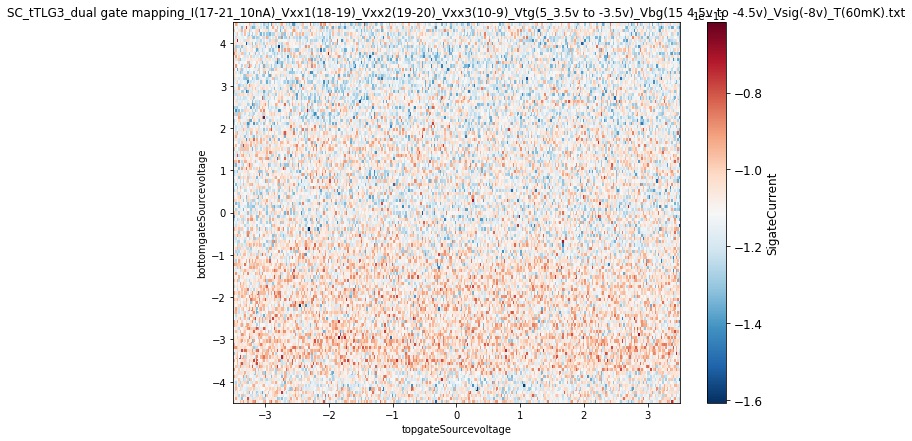

In [10]:
directory = 'C:/Users/jdiez/LDQM/a. Data/'
ttg_BGTG_folder='Chengs-trilayer-DGmap/'
ttg_BGTG_directory= directory+ttg_BGTG_folder

ttg_BGTG_files=[
        'SC_tTLG3_dual gate mapping_I(17-21_10nA)_Vxx1(18-19)_Vxx2(19-20)_Vxx3(10-9)_Vtg(5_3.5v to -3.5v)_Vbg(15 4.5v to -4.5v)_Vsig(-8v)_T(60mK).txt',
]

ttg_BGTG_obj = {} #stores all the data
BGTG_raw ={} #store the xaxis data for plotting
ttg_BGTG_variables={} #store the data to plot in the right units
ttg_BGTG_name={}

# All IV curves

for i in range(len(ttg_BGTG_files)):
    file=ttg_BGTG_directory+ttg_BGTG_files[i]
    ttg_BGTG_obj,ttg_BGTG_variables,ttg_BGTG_name=LDQM_dataplot.plot_map_fromfiles(file)

    

In [37]:
tg_TG=ttg_BGTG_obj.topgateSourcevoltage
tg_BG=ttg_BGTG_obj.bottomgateSourcevoltage
tg_I=ttg_BGTG_obj.Rxx_4_Top_currentX
tg_z=ttg_BGTG_obj.Rxx1X/tg_I/1000
tg_z2=ttg_BGTG_obj.Rxx_2X/tg_I/1000

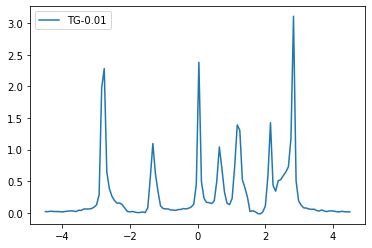

In [63]:
# Get the data from the back gate only 
line=150
len(tg_z[:])
plt.plot(tg_BG[:,line],tg_z[:,line],label='TG{0:.2f}'.format(tg_TG[0,150]))
plt.legend()
plt.show()

tg_BGonly=tg_BG[:,line]

In [73]:
# Make a perpendicular signal like this 

tg_BG_big=np.zeros_like(tg_z)
for i in range(len(tg_z)):
    tg_BG_big[:,i]=tg_BGonly

In [74]:
tg_BG_big

array([[-4.5       , -4.5       , -4.5       , ...,  0.        ,
         0.        ,  0.        ],
       [-4.42436975, -4.42436975, -4.42436975, ...,  0.        ,
         0.        ,  0.        ],
       [-4.3487395 , -4.3487395 , -4.3487395 , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 4.3487395 ,  4.3487395 ,  4.3487395 , ...,  0.        ,
         0.        ,  0.        ],
       [ 4.42436975,  4.42436975,  4.42436975, ...,  0.        ,
         0.        ,  0.        ],
       [ 4.5       ,  4.5       ,  4.5       , ...,  0.        ,
         0.        ,  0.        ]])

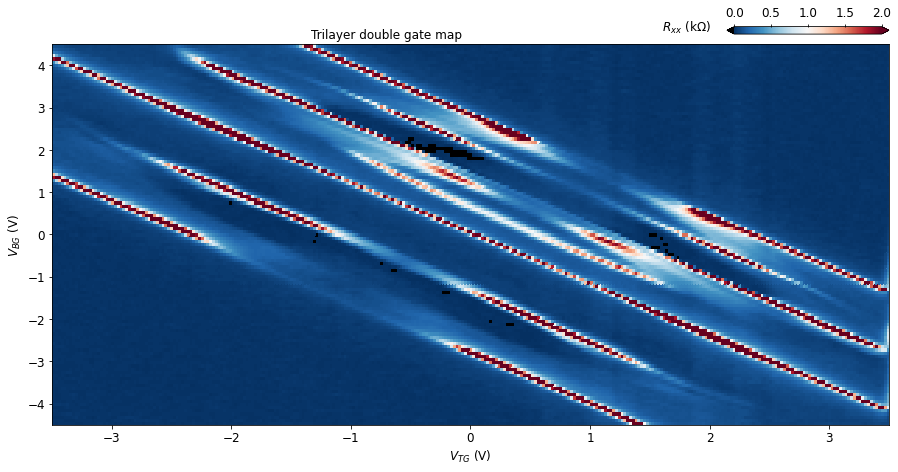

In [36]:


font=12
orig_cmap = matplotlib.cm.RdBu_r

mycolor=LDQM_dataplot.shiftedColorMap(0.5,orig_cmap)
    
fig=plt.figure(figsize=(15,7))

ax1=fig.add_subplot(111)
im=plt.pcolormesh(tg_TG,tg_BG,tg_z,cmap='RdBu_r',vmin=0,vmax=2)

im.cmap.set_under('black')
#im.cmap.set_over('white')

ax1.set_title('Trilayer double gate map',fontsize=font,position=(0.4,1))
ax1.set_xlabel('$V_{TG}$ (V)',fontsize=font)
ax1.set_ylabel('$V_{BG}$ (V)',fontsize=font)

### Add the colorbar 
cbaxes = fig.add_axes([0.75, 0.9, 0.15,0.015]) #left,bottom,width,heigth
cb = plt.colorbar(im,shrink=0.3,cax=cbaxes,orientation='horizontal',extend='both') 
cb.set_label('$R_{xx}$ (k$\Omega$)',fontsize=font,position=(-0.25,1), labelpad=-15,rotation=0)
cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font)

ax1.tick_params(axis='both', which='major', labelsize=font)

#ax1.set_yticklabels(fontsize=font,rotation=0)
    
#plt.plot(x[0],-1.136*x[0]-1.5,'orange',linestyle='dashed',linewidth=2)
#ax1.set_xlim(-2.5,2.5)
#ax1.set_ylim(-3,3)
#fig.tight_layout()
#if save:
#    plt.savefig(savename+'Ju1-ICE2104_DGate-Rxx14-16_labels_seismic'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
#    savecount=savecount+1
plt.show()


In [ ]:

if linefits==True:
    # From main
    ax1.plot(x[0],-1.136*x[0],'grey',linestyle='dashed',linewidth=1)
    ax1.plot(x[0],-1.136*x[0]-1.3,'grey',linestyle='dashed',linewidth=1)
    ax1.plot(x[0],-1.136*x[0]+1.2,'grey',linestyle='dashed',linewidth=1)
    ax1.plot(x[0],-1.136*x[0]-2.6,'grey',linestyle='dashed',linewidth=1)
    ax1.plot(x[0],-1.136*x[0]+2.6,'grey',linestyle='dashed',linewidth=1)
    
    # From the cut 
    ax1.plot(x[0],-25*x[0],'g--',linewidth=1)
    ax1.plot(x[0],-25*x[0]-28.5,'g--',linewidth=1)
    ax1.plot(x[0],-25*x[0]+27,'g--',linewidth=1)
    ax1.plot(x[0],-25*x[0]+41,'g--',linewidth=1)
    
    # Line fits 
    #ax1.text(1.6,2.5,'Cut: y=-25*x+b',color='lime',fontsize=14,weight='bold')
    #ax1.text(-2.45,-2.8,'Main: y=-1.136*x+b',color='beige',fontsize=14,weight='bold')

    # Cut features 
    
    ax1.text(-1.5,1.9,r'$C_{-1/2}$',color='lime',fontsize=14,weight='bold')
    ax1.text(-0.23,2.15,r'$D$',color='lime',fontsize=14,weight='bold')
    ax1.text(0.8,1,r'$C_{1/2}$',color='lime',fontsize=14,weight='bold')
    ax1.text(1.4,0.5,r'$C_{3/4}$',color='lime',fontsize=14,weight='bold')
    
    # Main features 
    ax1.text(-2.4,0.5,r'$BI$',color='beige',fontsize=14,weight='bold')
    ax1.text(-2.4,1.5,r'$C_{-1/2}$',color='beige',fontsize=14,weight='bold')
    ax1.text(-2.4,2.4,r'$D$',color='beige',fontsize=14,weight='bold')
    ax1.text(2.3,-1.7,r'$C_{1/2}$',color='beige',fontsize=14,weight='bold')
    ax1.text(2.3,-0.3,r'$BI$',color='beige',fontsize=14,weight='bold')
    
    
    # Dirac crossing 
    #plt.plot(-0.01, 0, "ko")
    #plt.plot(-1.2, 1.35, "ko")
    #plt.plot(1.13, -1.28, "ko")
    #plt.plot(1.72, -1.95, "ko")
    
    
    # JJ points 
    
    ax1.plot(-1.3, -0.1, "wD",linewidth=4)
    ax1.text(-1.55, -0.1,'SSS',color='w',fontsize=14,weight='bold',rotation=-30)
    
    ax1.plot(-1.12, -0.3, "wD",linewidth=4)
    ax1.text(-1.1, -0.6,'SCS',color='w',fontsize=14,weight='bold',rotation=-30)
    
    ax1.plot(-0.7, -0.8, "wD",linewidth=4)
    ax1.text(-0.7, -1.15,'SNS',color='w',fontsize=14,weight='bold',rotation=-30)
    
    ax1.plot(0.07, -1.65, "wD",linewidth=4)
    ax1.text(0.1, -2,'SDS',color='w',fontsize=14,weight='bold',rotation=-30)
   

## Simulate twist angle 

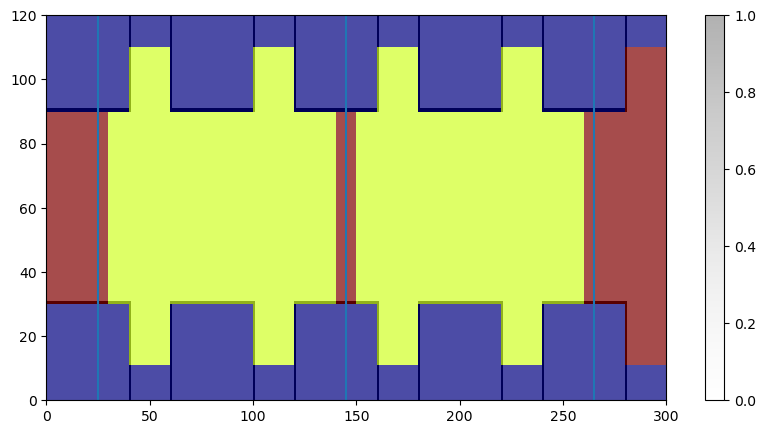

In [23]:
### Cuts in everyelectrode

# parallel plate capacitor

# Set dimensions of the problem
HB_width=30  # half of the real width 
HB_len=300
arms_width=10  # half of the real width
arms_len=30
gr_top_width=50
gr_bot_width=40
num_arms=6
arms_dis=int(HB_len/num_arms)

cut_width=5
cut1=int(arms_dis/2)
cut2=2*(arms_dis+arms_width)+int(arms_dis/2)
cut3=4*(arms_dis+arms_width)+int(arms_dis/2)



Nx=HB_len
Ny=2*HB_width+2*arms_len
center_x=int(Nx/2)
center_y=int(Ny/2)

x=np.arange(0,Nx+1,1)
y=np.arange(0,Ny+1,1)
x_real=np.arange(-center_x,center_x+1,1)
y_real=np.arange(-center_y,center_y+1,1)

X,Y=np.meshgrid(x,y)
X_R,Y_R=np.meshgrid(x_real,y_real)
# Make the matrix for the hall bar shape. In np.zeros, the order is inverted

border=np.zeros((Ny,Nx))

# Make the zeros for the carrier density guess for out matrix --> All 0s

n=np.zeros((Ny,Nx))
V_top=np.zeros((Ny,Nx))
V_bot=np.zeros((Ny,Nx))
C_bot=0.0058/1.602E-19/1E4*0.56
C_top=0.0058/1.602E-19/1E4
# Hall bar width lets make it 100, length 300, arms every 50 with width of 10 and length of 20
### lets give a value of 1 to the border, so I plot in black and white just the border of the hall bar

count=0
for k in range(num_arms):
    for j in range(Nx):
        for i in range(Ny):
            if j in range(0+count,(arms_dis-arms_width)+count):
                if i==center_y-HB_width or i==center_y+HB_width:
                    border[i,j]=1
            if j==(arms_dis-arms_width)+count and i>=center_y+HB_width:
                border[i,j]=1   
            if j ==(arms_dis+arms_width)+count and i>=center_y+HB_width:
                border[i,j]=1   
            if j==(arms_dis-arms_width)+count and i<=center_y-HB_width:
                border[i,j]=1   
            if j==(arms_dis+arms_width)+count and i<=center_y-HB_width:
                border[i,j]=1 
    count=count+(arms_dis+arms_width)
    
### Fill the resistance values

V_bg=0.9
V_tg1=0
V_tg2=-0.2
V_tg3=-0.2
V_tg4=0
V_tg5=0
V_tg6=0

count=0
for j in range(Nx):
    for i in range(Ny):
        # Left of 1st cut
        if j in range(0,cut1-cut_width):
            for i in range(center_y-HB_width,center_y+HB_width):
                V_top[i,j]=V_tg1
                V_bot[i,j]=V_bg
                
        # Inside of 1st cut
        if j in range(cut1-cut_width,cut1+cut_width):
            for i in range(center_y-HB_width,center_y+HB_width):
                V_top[i,j]=0
                V_bot[i,j]=V_bg
                
        # Between two cuts
        if j in range(cut1+cut_width,cut2-cut_width):
            for i in range(center_y-HB_width,center_y+HB_width):
                V_top[i,j]=V_tg2
                V_bot[i,j]=V_bg
                
        # Inside of 2nd cut
        if j in range(cut2-cut_width,cut2+cut_width):
            for i in range(center_y-HB_width,center_y+HB_width):
                V_top[i,j]=0
                V_bot[i,j]=V_bg
                
        # Right of 2nd cut
        if j in range(cut2+cut_width,cut3-cut_width):
            for i in range(center_y-HB_width,center_y+HB_width):
                V_top[i,j]=V_tg3
                V_bot[i,j]=V_bg
        # Inside of 3nd cut
        if j in range(cut3-cut_width,cut3+cut_width):
            for i in range(center_y-HB_width,center_y+HB_width):
                V_top[i,j]=0
                V_bot[i,j]=V_bg
                
        # Right of 3nd cut
        if j in range(cut3+cut_width,Nx):
            for i in range(center_y-HB_width,center_y+HB_width):
                V_top[i,j]=V_tg4
                V_bot[i,j]=V_bg

                
### This is the arms 

for k in range(num_arms):
    for j in range(Nx):
        for i in range(Ny):
            
            if j in range(arms_dis-arms_width+count,arms_dis+arms_width+count):
                if i>=center_y+HB_width and i<center_y+gr_top_width:
                    V_top[i,j]=V_top[center_y,j]   
                    V_bot[i,j]=V_bot[center_y,j]  
                elif i>=center_y+gr_top_width and i<center_y+gr_bot_width:
                    V_top[i,j]=0  
                    V_bot[i,j]=V_bot[center_y,j]  
                elif i<=center_y-gr_bot_width and i>center_y-gr_top_width:
                    V_top[i,j]=V_top[center_y,j]  
                    V_bot[i,j]=0
                    
            if j in range(arms_dis-arms_width+count,arms_dis+arms_width+count):
                if i<=center_y-HB_width and i>center_y-gr_top_width:
                    V_top[i,j]=V_top[center_y,j]   
                    V_bot[i,j]=V_bot[center_y,j]  
                elif i<=center_y-gr_top_width and i>center_y-gr_bot_width:
                    V_top[i,j]=0  
                    V_bot[i,j]=V_bot[center_y,j]  
                elif i<=center_y-gr_bot_width and i>center_y-gr_top_width:
                    V_top[i,j]=V_top[center_y,j]  
                    V_bot[i,j]=0
                
    count=count+(arms_dis+arms_width)

n=V_top*C_top+V_bot*C_bot  

R=np.zeros_like(n)
I=np.zeros_like(n)
for i in range(len(n)):
    for j in range(len(n[0])):
        R[i,j]=get_R(n[i,j],nbg,Rbg)
        I[i,j]=get_I(n[i,j],nbg,Ibg)
    
plt.figure(figsize=(10,5))    

plt.axvline(x=cut1)
plt.axvline(x=cut2)
plt.axvline(x=cut3)
plt.pcolormesh(X,Y,n,cmap='jet')
plt.pcolormesh(X,Y,border,cmap='Greys',alpha=0.3)
plt.colorbar()
plt.show()
